#### Institute of Data Capstone Project
# 📚 Books Don't Die, They Slow Down
##### Notebook 3 of 4 · Forecasting
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

Research Question
> Can monthly book demand be forecast more accurately than last year's figure for the same month?

## Table of Contents

1. [Setup](#setup)
2. [Target series](#target)
3. [Order identification](#order)
4. [Classical models](#classical)
5. [Machine-learning models](#ml)
6. [Evaluation](#evaluation)
7. [Forward forecast](#forecast)
8. [Conclusion](#conclusion)

<a id="setup"></a>
## 1. Setup

Classical time-series models and machine-learning regressors are fitted to **one** series, scored with **one** error scale, on **one** set of cross-validation folds, so the comparison in §6 is like-for-like.

In [1]:
%load_ext autoreload
%autoreload 2
# ^ line magics consume the whole line as arguments: comments go below.

from capstone import *

df        = load_scoped()          # sales_scoped.parquet
POP_TABLE = populations()          # raises if parquet and JSON came from different runs
display(POP_TABLE[["lines", "units", "isbns", "months"]])

scoped   94,872 lines · 180 months · contract v1


,lines,units,isbns,months
filter,,,,
composition,94872,653584.51,640,180
all,94872,653584.51,640,180
units_observable,94510,653584.51,640,180
demand,83346,541817.00,639,180
genre,81336,531424.00,552,180
net_revenue,90662,497985.00,640,180
returns,7316,-43832.00,491,177
price_vol,74990,456266.00,632,180
revenue_ts,83614,555279.00,639,180


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotx, colorcet as cc

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from sklearn.base            import clone

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters        import ExponentialSmoothing
from statsmodels.stats.diagnostic       import acorr_ljungbox
from statsmodels.graphics.tsaplots      import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# ── Style: same palette as notebook 2 ───────────────────────────────────────
# Every notebook draws from the same palette; without this, two figures of the
# same type would land side by side in different colours.
STYLE = matplotx.styles.tokyo_night["night"]
mpl.rcParams.update(STYLE)
DARK = mpl.colors.rgb_to_hsv(
    mpl.colors.to_rgb(mpl.rcParams["figure.facecolor"]))[2] < 0.5

CAT = ["#7AA2F7", "#E0AF68", "#9ECE6A", "#BB9AF7", "#7DCFFF",
       "#FF9E64", "#73DACA", "#C3A6FF", "#B4F9F8", "#D5A0C0"]
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=CAT)
FG   = mpl.rcParams["text.color"]
GREY = "#8A8FA3" if DARK else "#C4C4C4"   # de-emphasised series
NEG  = "#F7768E" if DARK else "#C0392B"   # reference rules that signal a threshold
RULE = "#565F89" if DARK else "#999999"   # event lines, reference rules

# Column handles
DATE_COL = [c for c in df.columns if df[c].dtype.kind == "M"][0]
assert isinstance(FILTERS, dict), "FILTERS was rebound: re-run the first cell"
print(f"frame {len(df):,} lines · {df[DATE_COL].min():%Y-%m} → {df[DATE_COL].max():%Y-%m}")

frame 94,872 lines · 2011-08 → 2026-07


<a id="target"></a>
## 2. Target series

One number per month: GROSS book units (`demand` filter, returns excluded), August 2011 to July 2026. Units, not revenue, because units are what the client plans print runs and stock against.

In [3]:
# ── 2.1 Target series ───────────────────────────────────────────────────────
# Built by monthly_series(), the single sanctioned builder: it applies the
# contract filter, groups on ym_ts, and asfreq("MS") so the index is regular.
POP_KEY   = "demand"
VALUE_COL = "Qty"
BASIS     = "GROSS units, book sales excl. returns"
M, H      = 12, 12                 # seasonal period · holdout length

y = monthly_series(POP_KEY, VALUE_COL)

# Guardrails capable of failing on plausible data
assert len(y) == 180, f"expected 180 months, got {len(y)}"
assert y.index.is_monotonic_increasing, "months out of order"
assert y.index.freqstr == "MS", "index lost monthly frequency: lags will misalign"
assert y.notna().all(), f"{y.isna().sum()} calendar gaps: positional shift() would misalign"
assert (y > 0).all(), "zero/negative months: log undefined"
# ↑ the freq and notna asserts are the important pair. Lag features are built
#   with .shift(), which is POSITIONAL. On a series with holes, shift(12) does
#   not reach back twelve calendar months.

_lines = int(POP_TABLE.loc[POP_KEY, "lines"])
assert _lines == len(pop(POP_KEY)), "registry and live filter disagree"

print(f"Series: {len(y)} months · {y.index.min():%Y-%m} → {y.index.max():%Y-%m} "
      f"· mean {y.mean():,.0f} units/month")
print(f"Scope : {POP_KEY} · {_lines:,} lines")

Series: 180 months · 2011-08 → 2026-07 · mean 3,010 units/month
Scope : demand · 83,346 lines


In [4]:
# ── 2.2 Ramp check: is the register start a different regime? ─────────────
# A trim is defensible only as a REGIME argument, not for calendar tidiness.
for lbl, s in [("Aug–Dec 2011", y.loc[:"2011-12"]), ("2012", y.loc["2012"]),
               ("2013", y.loc["2013"]), ("2014", y.loc["2014"])]:
    print(f"{lbl:14s} mean {s.mean():>8,.0f}   min {s.min():>7,.0f}   max {s.max():>7,.0f}")
# → 2011 far below 2012, and 2012 below 2013 = a ramp; trim justified.
#   2011 inside the 2012 range = just the register start; keep it.

Aug–Dec 2011   mean    1,176   min     985   max   1,527
2012           mean    1,539   min     612   max   4,306
2013           mean    1,664   min     700   max   2,783
2014           mean    2,555   min     465   max   5,666


saved → figures/m01_monthly_units.png


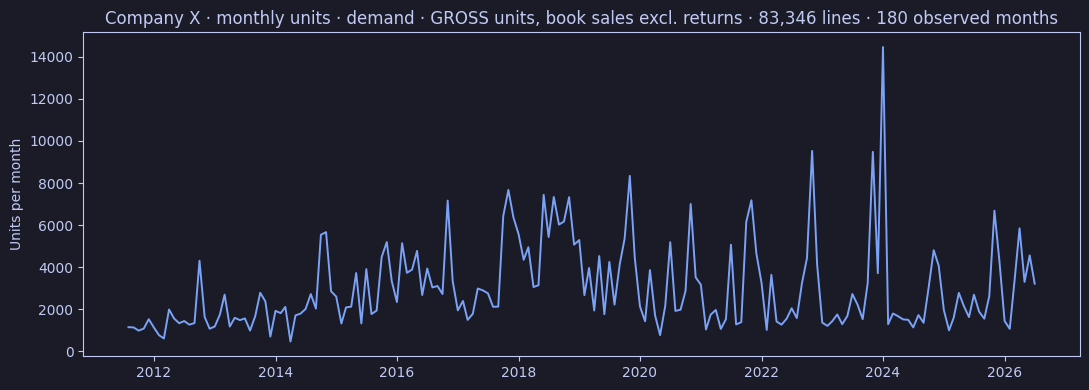

y_log · 180 observed of 180


In [5]:
# ── 2.3 Plot, and the case for a log scale ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y.index, y, lw=1.4, color=CAT[0])
ax.set_ylabel("Units per month")
ax.set_title(f"Company X · monthly units · {POP_KEY} · {BASIS} · "
             f"{_lines:,} lines · 180 observed months")
save_fig(fig, "m01_monthly_units")
plt.show()

# Seasonal amplitude grows with the level (multiplicative). Log stabilises the
# variance and prevents any model from forecasting negative units.
y_log = np.log(y)
print(f"y_log · {y_log.notna().sum()} observed of {len(y_log)}")

<a id="order"></a>
## 3. Order identification

Notebook 2 §5.7 measured the seasonal structure with STL. Here the first-differenced series is read for candidate SARIMA orders: spikes at lags 12, 24 and 36 point to seasonal terms, and decay between them points to the non-seasonal order.

saved → figures/m02_acf_pacf.png


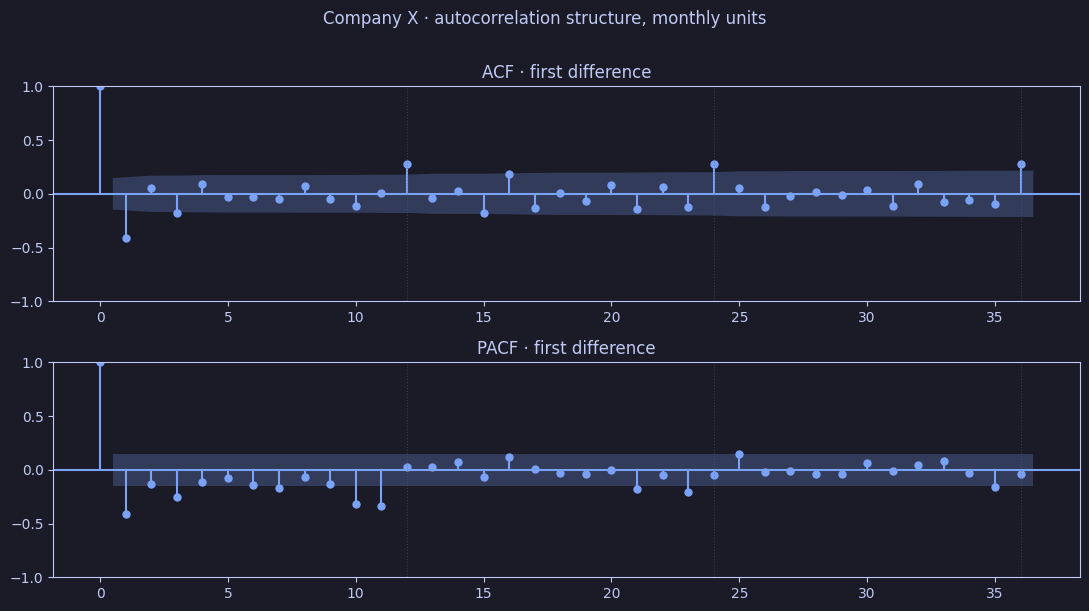

In [6]:
# ── 3.1 ACF / PACF on the first difference ─────────────────────────────────
# 36 lags = 3 seasonal cycles.
d1 = y.diff().dropna()
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
plot_acf(d1, lags=36, ax=ax[0], title="ACF · first difference", color=CAT[0],
         vlines_kwargs={"colors": CAT[0]})
plot_pacf(d1, lags=36, ax=ax[1], title="PACF · first difference", method="ywm",
          color=CAT[0], vlines_kwargs={"colors": CAT[0]})
for a in ax:
    for lag in (12, 24, 36):
        a.axvline(lag, ls=":", lw=.8, alpha=.5, color=RULE)
fig.suptitle("Company X · autocorrelation structure, monthly units", y=1.01)
save_fig(fig, "m02_acf_pacf")
plt.show()

<a id="classical"></a>
## 4. Classical models

Three classical candidates, fitted on the log scale where relevant:

* **Seasonal naive**: next August = last August. The benchmark every model must beat; if none do, that is the finding.
* **SARIMA**: ten candidate orders, selected on AIC among those whose residuals pass Ljung-Box (p > 0.05, no pattern left). Non-differenced variants are in the grid, so differencing is tested rather than assumed.
* **Holt-Winters**: additive trend and seasonality on log units, which is multiplicative on the original scale.

The holdout is the final 12 months (August 2025 to July 2026): one full seasonal cycle.

In [7]:
# ── 4.1 SARIMA order selection on the training span ────────────────────────
train_log = y_log.iloc[:-H]
assert len(train_log) == 168, "training span should be 168 months"

GRID = [((1,1,1),(1,1,1,12)), ((0,1,1),(0,1,1,12)), ((1,1,0),(1,1,0,12)),
        ((2,1,1),(1,1,1,12)), ((1,1,1),(0,1,1,12)), ((0,1,1),(1,1,1,12)),
        ((0,1,1),(0,1,2,12)), ((1,1,1),(2,1,1,12)),
        ((1,0,1),(1,1,1,12)), ((1,1,1),(1,0,1,12))]

rows = []
for order, sorder in GRID:
    try:
        f = SARIMAX(train_log, order=order, seasonal_order=sorder,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        # Ljung-Box on residuals after the first seasonal cycle
        lb = acorr_ljungbox(f.resid[M:], lags=[12], return_df=True)["lb_pvalue"].iloc[0]
        rows.append({"order": order, "seasonal": sorder,
                     "AIC": f.aic, "BIC": f.bic, "LjungBox_p": lb, "_fit": f})
    except Exception as e:
        print(f"FAILED {order}{sorder}: {type(e).__name__}")

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
print(grid.drop(columns="_fit").round(3).to_string())

# Lowest AIC among models whose residuals pass the white-noise test
ok = grid[grid.LjungBox_p > 0.05]
best = (ok if len(ok) else grid).iloc[0]
SARIMA_FIT   = best._fit
SARIMA_ORDER = (best.order, best.seasonal)
SARIMA_LABEL = f"SARIMA {best.order}{best.seasonal}"
print(f"\nSelected {SARIMA_LABEL} · AIC {best.AIC:.1f} · "
      f"Ljung-Box p={best.LjungBox_p:.3f}" + ("" if len(ok) else "  ⚠ none passed"))
# AIC is comparable only within this log-scale table.

       order       seasonal      AIC      BIC  LjungBox_p
0  (0, 1, 1)  (0, 1, 2, 12)  181.568  193.007       0.173
1  (1, 1, 1)  (2, 1, 1, 12)  182.186  199.391       0.000
2  (1, 0, 1)  (1, 1, 1, 12)  194.695  209.475       0.071
3  (0, 1, 1)  (1, 1, 1, 12)  195.637  207.432       0.025
4  (0, 1, 1)  (0, 1, 1, 12)  195.644  204.491       0.297
5  (1, 1, 1)  (0, 1, 1, 12)  197.530  209.325       0.318
6  (1, 1, 1)  (1, 1, 1, 12)  197.626  212.369       0.026
7  (2, 1, 1)  (1, 1, 1, 12)  199.604  217.296       0.030
8  (1, 1, 1)  (1, 0, 1, 12)  221.606  236.759       0.342
9  (1, 1, 0)  (1, 1, 0, 12)  245.183  254.050       0.001

Selected SARIMA (0, 1, 1)(0, 1, 2, 12) · AIC 181.6 · Ljung-Box p=0.173


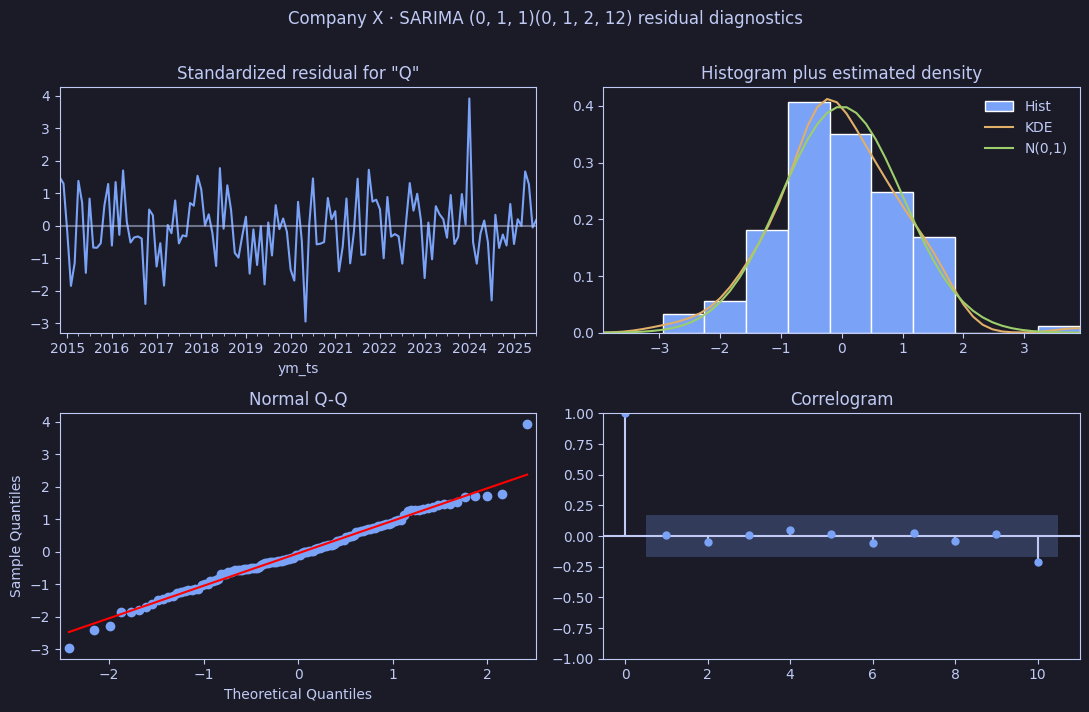

In [8]:
# ── 4.2 Residual diagnostics for the selected SARIMA ──────────────────────
fig = SARIMA_FIT.plot_diagnostics(figsize=(11, 7))
fig.suptitle(f"Company X · {SARIMA_LABEL} residual diagnostics", y=1.01)
plt.tight_layout()
plt.show()

<a id="ml"></a>
## 5. Machine-learning models

Regressors cannot read a time series directly, so the series is turned into a table: one row per month, with features describing the same months last year.

In [9]:
# ── 5.1 Feature engineering ───────────────────────────────────────────────
X = pd.DataFrame(index=y.index)

# (a) LAGS. Publishing demand is strongly annual (school terms, festival and
#     gift season). Every lag >= 12 months, so a 12-month-ahead forecast never
#     feeds its own predictions back in: no error compounding.
# MODIFY: adding lag_1..lag_11 improves fit but forces recursive forecasting.
for L in (12, 13, 24):
    X[f"lag_{L}"] = y.shift(L)

# (b) ROLLING SUMMARIES. Level and volatility of the same month last year.
#     shift(12) FIRST, then roll: rolling first peeks at the target (leakage).
X["roll12_mean"] = y.shift(12).rolling(12).mean()
X["roll12_std"]  = y.shift(12).rolling(12).std()

# (c) CYCLICAL ENCODING. A raw integer 1–12 tells the model December is eleven
#     units from January, which is false: they are adjacent. sin/cos wraps the
#     calendar into a circle.
m = X.index.month
X["mo_sin"] = np.sin(2 * np.pi * m / 12)
X["mo_cos"] = np.cos(2 * np.pi * m / 12)

# (d) REGIME DUMMY. Culture Pass from 2026-03. Descriptive only: the model may
#     use it; no causal claim is made or supported.
X["cp_flag"] = (X.index >= pd.Timestamp("2026-03-01")).astype(int)

# (e) TREND INDEX. Ridge can extrapolate a linear trend; tree models CANNOT,
#     because they only predict values seen in training. That asymmetry is a finding.
X["t"] = np.arange(len(X))

valid  = X.notna().all(axis=1)          # only lag warm-up rows are dropped
X, yv  = X[valid], y[valid]

assert yv.index.equals(X.index), "feature and target indices diverged"
assert X.notna().all().all(),    "NaN survived into the design matrix"

print(f"Design matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Dropped {(~valid).sum()} warm-up rows · span {X.index.min():%Y-%m} → {X.index.max():%Y-%m}")
print("Features:", list(X.columns))

Design matrix: 156 rows × 9 features
Dropped 24 warm-up rows · span 2013-08 → 2026-07
Features: ['lag_12', 'lag_13', 'lag_24', 'roll12_mean', 'roll12_std', 'mo_sin', 'mo_cos', 'cp_flag', 't']


In [10]:
# ── 5.2 Chronological split and the shared error scale ─────────────────────
# NEVER shuffle a time series: it trains on the future to predict the past.
cut_idx  = len(yv) - H
Xtr, Xte = X.iloc[:cut_idx], X.iloc[cut_idx:]
ytr, yte = yv.iloc[:cut_idx], yv.iloc[cut_idx:]

# MASE denominator: in-sample seasonal-naive MAE over the training span, on the
# calendar-complete series so shift(12) means twelve calendar months.
# One denominator for every model in this notebook, ML and classical alike.
ytr_cal = y.loc[:ytr.index.max()]
denom   = (ytr_cal - ytr_cal.shift(12)).abs().mean()
assert denom > 0 and np.isfinite(denom), "degenerate MASE denominator"

def score(y_true, y_pred, name):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"model": name,
            "MASE": mean_absolute_error(y_true, y_pred) / denom,        # decides
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),        # selects
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100}  # communicates

print(f"Train {ytr.index.min():%Y-%m} → {ytr.index.max():%Y-%m}  ({len(ytr)} months)")
print(f"Test  {yte.index.min():%Y-%m} → {yte.index.max():%Y-%m}  ({len(yte)} months)")
print(f"MASE denominator: {denom:,.1f} units (calendar seasonal naive, training span)")

Train 2013-08 → 2025-07  (144 months)
Test  2025-08 → 2026-07  (12 months)
MASE denominator: 1,344.7 units (calendar seasonal naive, training span)


In [11]:
# ── 5.3 Cross-validated hyperparameter search ──────────────────────────────
# TimeSeriesSplit = expanding window. Fold 2 absorbs fold 1's validation into
# training; nothing is validated on data preceding its own training set.
# Press-check analogy: approve sheet 400 with a proof pulled at 400, never 900.
CV = TimeSeriesSplit(n_splits=5, test_size=12)   # MODIFY: fewer splits = faster
assert len(Xtr) - CV.n_splits * 12 >= 24, "not enough history for 5 folds of 12"

GRIDS = {
    "Ridge (ML)": (
        Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
        {"m__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    "RandomForest (ML)": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"n_estimators":     [300],
         "max_depth":        [3, 5, None],
         "min_samples_leaf": [1, 3, 5]},
    ),
    "HistGradientBoosting (ML)": (
        HistGradientBoostingRegressor(random_state=42),
        {"learning_rate":    [0.03, 0.1],
         "max_iter":         [200, 400],
         "max_leaf_nodes":   [7, 15],
         "min_samples_leaf": [5, 10]},
    ),
}

results, best_params, preds = [], {}, {}
for name, (est, param_grid) in GRIDS.items():
    gs = GridSearchCV(est, param_grid, cv=CV, scoring="neg_mean_absolute_error",
                      n_jobs=-1, refit=True)
    gs.fit(Xtr, ytr)                       # search sees TRAIN ONLY
    p = gs.predict(Xte)
    preds[name], best_params[name] = pd.Series(p, index=yte.index), gs.best_params_
    r = score(yte, p, name)
    r["cv_MASE"] = -gs.best_score_ / denom
    results.append(r)
    print(f"{name:28s} cv_MASE {r['cv_MASE']:.3f} → holdout {r['MASE']:.3f} | {gs.best_params_}")

Ridge (ML)                   cv_MASE 1.124 → holdout 1.364 | {'m__alpha': 10.0}


RandomForest (ML)            cv_MASE 0.971 → holdout 1.039 | {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}


HistGradientBoosting (ML)    cv_MASE 0.979 → holdout 1.030 | {'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 5}


In [12]:
# ── 5.4 Fold-level scores for the tuned ML models ──────────────────────────
# Refits the winning hyperparameters across the SAME folds with the SAME
# denominator the classical models use in §6. Cheap: 3 models × 5 fits.
ml_folds = {}
for name, (est, _grid) in GRIDS.items():
    e, scores = clone(est).set_params(**best_params[name]), []
    for tr_i, te_i in CV.split(Xtr):
        e.fit(Xtr.iloc[tr_i], ytr.iloc[tr_i])
        p = e.predict(Xtr.iloc[te_i])
        scores.append(float(np.mean(np.abs(ytr.iloc[te_i] - p)) / denom))
    ml_folds[name] = scores
    print(f"{name:28s} cv_MASE {np.mean(scores):.3f} ± {np.std(scores):.3f}  "
          f"folds {[round(s, 3) for s in scores]}")

Ridge (ML)                   cv_MASE 1.124 ± 0.416  folds [1.812, 0.841, 0.587, 1.272, 1.11]


RandomForest (ML)            cv_MASE 0.971 ± 0.239  folds [1.188, 0.902, 0.561, 1.226, 0.98]


HistGradientBoosting (ML)    cv_MASE 0.979 ± 0.357  folds [1.571, 0.778, 0.558, 1.178, 0.809]


<a id="evaluation"></a>
## 6. Evaluation

Every model is scored twice: on the single 12-month holdout, and on five rolling origins that share the ML folds. Models are **ranked on cross-validated MASE**, because five windows beat one; the holdout stays visible so any gap between the two is on the record.

* **MASE decides**: below 1.0 means better than the seasonal naive benchmark on the training span.
* **RMSE selects** between close candidates.
* **MAPE communicates**, but is asymmetric and footnoted wherever shown.

In [13]:
# ── 6.1 Classical benchmarks + rolling-origin CV + comparison table ─────────
results = [r for r in results if "(ML)" in r["model"]]   # idempotent re-runs

def fit_forecast(kind, hist, out_index):
    """Fit one classical model on log history; return forecasts on out_index.

    Forecasts across the full calendar horizon, then reindexes: never forecast
    a shortened index, or the step count silently disagrees with the dates.
    """
    hl = np.log(hist.clip(lower=1))
    if kind == "hw":
        f = ExponentialSmoothing(hl.values, trend="add", seasonal="add",
                                 seasonal_periods=12).fit()
    else:
        f = SARIMAX(hl.values, order=SARIMA_ORDER[0], seasonal_order=SARIMA_ORDER[1],
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    idx = pd.date_range(hist.index[-1] + pd.DateOffset(months=1),
                        out_index[-1], freq="MS")
    return pd.Series(np.exp(f.forecast(len(idx))), index=idx).reindex(out_index)

# ── a · Holdout ─────────────────────────────────────────────────────────────
sn = y.shift(12).reindex(yte.index)                   # 12 CALENDAR months back
assert sn.notna().all(), "seasonal-naive lag reached outside the series"
preds["Seasonal naive (baseline)"] = sn
preds["Holt-Winters (classical)"]  = fit_forecast("hw",  ytr_cal, yte.index)
preds[SARIMA_LABEL]                = fit_forecast("sar", ytr_cal, yte.index)
for name in ["Seasonal naive (baseline)", "Holt-Winters (classical)", SARIMA_LABEL]:
    results.append(score(yte, preds[name], name))

# SARIMA 80% interval coverage on the holdout: does the band hold ~80% of actuals?
ci_hold = np.exp(SARIMA_FIT.get_forecast(steps=H).conf_int(alpha=0.20))
ci_hold = pd.DataFrame(np.asarray(ci_hold), index=yte.index)
COVERAGE = ((yte >= ci_hold[0]) & (yte <= ci_hold[1])).mean()
print(f"SARIMA 80% interval coverage on holdout: {COVERAGE:.0%} (target ~80%)")

# ── b · Rolling-origin CV, same folds as GridSearchCV ───────────────────────
# Each fold refits from scratch on history up to that origin: no forward leakage.
cv_rows = {"Seasonal naive (baseline)": [],
           "Holt-Winters (classical)":  [],
           SARIMA_LABEL:                []}

for k, (tr_i, te_i) in enumerate(CV.split(Xtr), 1):
    tr_end  = ytr.index[tr_i[-1]]
    fold_te = ytr.index[te_i]
    actual  = ytr.loc[fold_te]
    hist    = y.loc[:tr_end]                 # calendar-complete history

    cv_rows["Seasonal naive (baseline)"].append(
        float((actual - y.shift(12).reindex(fold_te)).abs().mean() / denom))
    cv_rows["Holt-Winters (classical)"].append(
        float((actual - fit_forecast("hw", hist, fold_te)).abs().mean() / denom))
    cv_rows[SARIMA_LABEL].append(                        # slowest step
        float((actual - fit_forecast("sar", hist, fold_te)).abs().mean() / denom))
    print(f"  fold {k}: train → {tr_end:%Y-%m}, score {fold_te.min():%Y-%m}–{fold_te.max():%Y-%m}")

for name, folds in cv_rows.items():
    for r in results:
        if r["model"] == name:
            r["cv_MASE"] = float(np.mean(folds))
    print(f"{name:28s} cv_MASE {np.mean(folds):.3f} ± {np.std(folds):.3f}  "
          f"folds {[round(x, 3) for x in folds]}")

# ── c · Comparison table ────────────────────────────────────────────────────
comp = (pd.DataFrame(results).sort_values("cv_MASE").reset_index(drop=True)
          .loc[:, ["model", "cv_MASE", "MASE", "RMSE", "MAPE"]]
          .rename(columns={"MASE": "holdout_MASE"}))
comp.insert(0, "rank", comp.index + 1)
assert comp["cv_MASE"].notna().all(), "a model has no cross-validated score"
display(comp.round(3))

SARIMA 80% interval coverage on holdout: 67% (target ~80%)


  fold 1: train → 2020-07, score 2020-08–2021-07
  fold 2: train → 2021-07, score 2021-08–2022-07


  fold 3: train → 2022-07, score 2022-08–2023-07
  fold 4: train → 2023-07, score 2023-08–2024-07


  fold 5: train → 2024-07, score 2024-08–2025-07
Seasonal naive (baseline)    cv_MASE 0.965 ± 0.281  folds [0.746, 0.719, 0.755, 1.218, 1.386]
Holt-Winters (classical)     cv_MASE 0.850 ± 0.332  folds [0.781, 0.92, 0.771, 1.404, 0.373]
SARIMA (0, 1, 1)(0, 1, 2, 12) cv_MASE 0.764 ± 0.269  folds [0.53, 0.765, 0.731, 1.265, 0.529]


,rank,model,cv_MASE,holdout_MASE,RMSE,MAPE
0,1,"SARIMA (0, 1, 1)(0, 1, 2, 12)",0.764,1.023,1803.486,44.284
1,2,Holt-Winters (classical),0.850,0.986,1694.787,39.750
2,3,Seasonal naive (baseline),0.965,0.792,1486.795,27.536
3,4,RandomForest (ML),0.971,1.039,1801.047,52.495
4,5,HistGradientBoosting (ML),0.979,1.030,1776.302,48.781
5,6,Ridge (ML),1.124,1.364,2479.481,73.991


saved → figures/m03_model_comparison.png


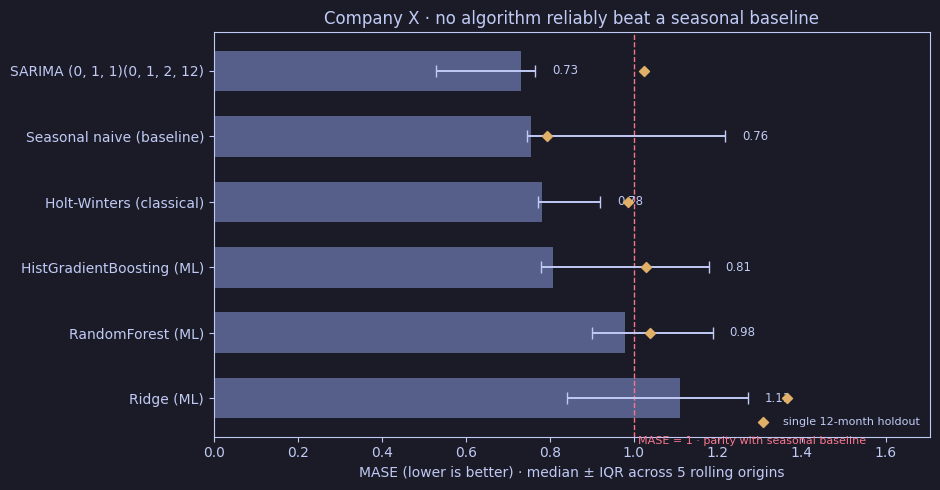

,model,median,iqr_lo,iqr_hi,holdout_MASE,n_bad
0,Ridge (ML),1.110,0.841,1.272,1.364,0
1,RandomForest (ML),0.980,0.902,1.188,1.039,0
2,HistGradientBoosting (ML),0.809,0.778,1.178,1.030,0
3,Holt-Winters (classical),0.781,0.771,0.920,0.986,0
4,Seasonal naive (baseline),0.755,0.746,1.218,0.792,0
5,"SARIMA (0, 1, 1)(0, 1, 2, 12)",0.731,0.530,0.765,1.023,0


In [14]:
# ── 6.2 Comparison figure: variability first ───────────────────────────────
# The honest finding may be that NOTHING separated. A ranked bar chart with a
# colour split would argue the opposite, so: one colour, error bars sized to
# the real fold-to-fold spread, and a shaded overlap band.
#
# Ranked on the MEDIAN fold score, not the mean: a single numerically diverged
# fit (reported below, never trimmed silently) would dominate a mean.
FOLD_SCORES = {**cv_rows, **ml_folds}
missing = set(comp["model"]) - set(FOLD_SCORES)
assert not missing, f"no fold scores for: {missing}"

DIVERGE_X = 10.0        # MODIFY: a fold >10x the model's own median is a failed fit

d = comp.copy()
d["folds"]  = d["model"].map(FOLD_SCORES)
d["median"] = d["folds"].map(np.median)
d["iqr_lo"] = d["folds"].map(lambda f: np.percentile(f, 25))
d["iqr_hi"] = d["folds"].map(lambda f: np.percentile(f, 75))
d["n_bad"]  = [sum(np.array(f) > DIVERGE_X * np.median(f)) for f in d["folds"]]

for _, r in d[d["n_bad"] > 0].iterrows():
    bad = [round(x, 1) for x in r["folds"] if x > DIVERGE_X * r["median"]]
    print(f"!! {r['model']}: {r['n_bad']} diverged fold(s) {bad} "
          f"vs median {r['median']:.3f}: excluded from the plot, disclosed in caption")

d = d.sort_values("median", ascending=False).reset_index(drop=True)  # best on top after barh

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh(d["model"], d["median"], color="#565f89", height=0.62, zorder=2)

# Error bars = interquartile range across the five rolling origins. IQR, not SD:
# SD is not robust to a diverged fold.
ax.errorbar(d["median"], d["model"],
            xerr=[d["median"] - d["iqr_lo"], d["iqr_hi"] - d["median"]],
            fmt="none", ecolor="#c0caf5", elinewidth=1.4, capsize=4, zorder=4)

# Overlap band: where EVERY model's IQR intersects. Non-empty means no model is
# distinguishable from any other at this sample size.
lo, hi = d["iqr_lo"].max(), d["iqr_hi"].min()
if lo < hi:
    ax.axvspan(lo, hi, color="#7aa2f7", alpha=0.12, zorder=1)
    ax.text((lo + hi) / 2, len(d) - 0.4, "all models overlap here",
            ha="center", fontsize=8, color="#7aa2f7")

ax.scatter(d["holdout_MASE"], d["model"], marker="D", s=26, color="#e0af68",
           zorder=5, label="single 12-month holdout")
ax.axvline(1.0, ls="--", lw=1, color="#f7768e", zorder=3)
ax.text(1.01, -0.7, "MASE = 1 · parity with seasonal baseline", fontsize=8, color="#f7768e")

for i, r in d.iterrows():
    star = " *" if r["n_bad"] else ""
    ax.text(r["iqr_hi"] + 0.04, i, f"{r['median']:.2f}{star}",
            va="center", fontsize=8.5, color="#c0caf5")

# xlim from the IQRs and holdout markers only: a diverged fold never enters.
ax.set_xlim(0, max(d["iqr_hi"].max(), d["holdout_MASE"].max()) * 1.25)
ax.set_xlabel("MASE (lower is better) · median ± IQR across 5 rolling origins")
ax.set_title("Company X · no algorithm reliably beat a seasonal baseline")
if (d["n_bad"] > 0).any():
    ax.text(0.99, -0.20, "* one fold diverged numerically and is excluded from the median",
            transform=ax.transAxes, ha="right", fontsize=7.5, color="#e0af68")
ax.legend(loc="lower right", fontsize=8, frameon=False)
save_fig(fig, "m03_model_comparison")
plt.show()

display(d[["model", "median", "iqr_lo", "iqr_hi", "holdout_MASE", "n_bad"]].round(3))

saved → figures/m04_holdout_comparison.png


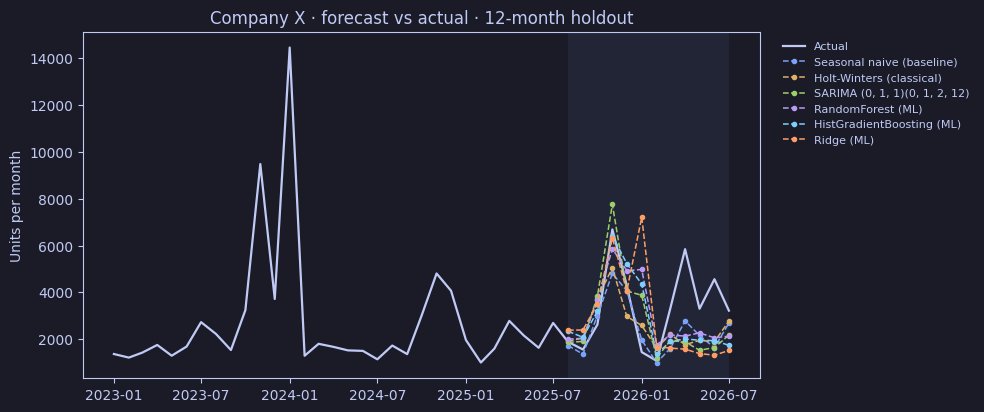

── holdout error by month, % of actual (negative = under-forecast) ──
         Ridge (ML)  RandomForest (ML)  HistGradientBoosting (ML)  Seasonal naive (baseline)  Holt-Winters (classical)  SARIMA (0, 1, 1)(0, 1, 2, 12)
ym_ts                                                                                                                                                
2025-08        26.0                6.0                       24.0                       -8.0                       1.0                           -1.0
2025-09        54.0               31.0                       34.0                      -13.0                      32.0                           23.0
2025-10        34.0               39.0                       22.0                       15.0                      42.0                           46.0
2025-11        -5.0              -12.0                       -4.0                      -28.0                     -24.0                           16.0
2025-12        -5.0           

In [15]:
# ── 6.3 Holdout forecasts against actuals ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(y.loc["2023":].index, y.loc["2023":], lw=1.6, color=FG, label="Actual")
for name in ["Seasonal naive (baseline)", "Holt-Winters (classical)", SARIMA_LABEL,
             "RandomForest (ML)", "HistGradientBoosting (ML)", "Ridge (ML)"]:
    ax.plot(preds[name].index, preds[name], lw=1.1, ls="--", marker="o", ms=3, label=name)
ax.axvspan(yte.index[0], yte.index[-1], alpha=.08, zorder=0)
ax.set_ylabel("Units per month")
ax.set_title("Company X · forecast vs actual · 12-month holdout")
ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False, fontsize=8)
fig.subplots_adjust(right=0.74)
save_fig(fig, "m04_holdout_comparison", tight=False)
plt.show()

err = pd.DataFrame({k: (v - yte) / yte * 100 for k, v in preds.items()}).round(0)
print("── holdout error by month, % of actual (negative = under-forecast) ──")
print(err.set_axis(err.index.strftime("%Y-%m")).to_string())

<a id="forecast"></a>
## 7. Forward forecast

The deployed model is refitted on all 180 months and forecasts 12 months forward (August 2026 to July 2027); the **first six are headlined**. Beyond that the interval widens past usefulness, and the widening fan is the honest answer to "how far can you see".

saved → figures/m05_forecast_12m.png


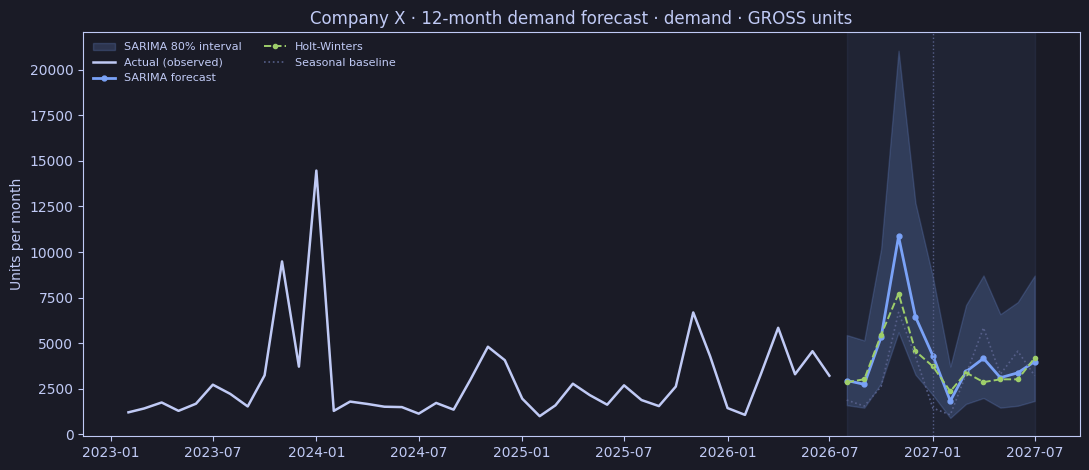

,forecast,low_80,high_80,baseline
2026-08,2953.0,1601.0,5446.0,1884.0
2026-09,2747.0,1464.0,5152.0,1553.0
2026-10,5334.0,2797.0,10173.0,2624.0
2026-11,10855.0,5601.0,21039.0,6688.0
2026-12,6448.0,3275.0,12696.0,4285.0
2027-01,4315.0,2158.0,8627.0,1444.0



Next 6 months, central estimate: 32,653 units (+76.7% vs the same months last year)
80% range: 16,897 – 63,133 units
Holt-Winters cross-check: 27,358 units (-16.2% vs SARIMA)
Holdout coverage of the 80% band was 67%: treat the band as a floor.


In [16]:
# ── 7.1 12-month forward forecast (headline: first 6 months) ───────────────
# Deployment: SARIMA. It ranks first on cross-validated MASE, but it lost to
# the baseline in two of five folds and on the holdout (§6), so it is deployed
# for its native prediction intervals rather than as a clear winner.
# Holt-Winters is plotted as a cross-check: if two independent methods
# diverge, distrust both.
FH, HEADLINE, HIST_SHOW = 12, 6, 42        # MODIFY: horizon · months quoted · history drawn

fut = pd.date_range(y.index[-1] + pd.DateOffset(months=1), periods=FH, freq="MS")

sar_f = SARIMAX(y_log.values, order=SARIMA_ORDER[0], seasonal_order=SARIMA_ORDER[1],
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
res   = sar_f.get_forecast(steps=FH)
mean  = pd.Series(np.exp(res.predicted_mean), index=fut)
ci80  = np.exp(res.conf_int(alpha=0.20))
lo80  = pd.Series(ci80[:, 0], index=fut)
hi80  = pd.Series(ci80[:, 1], index=fut)

hw_f  = ExponentialSmoothing(y_log.values, trend="add", seasonal="add",
                             seasonal_periods=12).fit()
hw_p  = pd.Series(np.exp(hw_f.forecast(FH)), index=fut)
naive = pd.Series(y.iloc[-12:].values, index=fut)     # reference line, not a competitor

hist = y.iloc[-HIST_SHOW:]
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axvspan(fut.min(), fut.max(), color="#7aa2f7", alpha=0.07)
ax.fill_between(fut, lo80, hi80, color="#7aa2f7", alpha=0.20, label="SARIMA 80% interval")
ax.plot(hist.index, hist, color="#c0caf5", lw=1.8, label="Actual (observed)")
ax.plot(fut, mean,  color="#7aa2f7", lw=2,   marker="o", ms=3.5, label="SARIMA forecast")
ax.plot(fut, hw_p,  color="#9ece6a", lw=1.4, ls="--", marker="o", ms=3, label="Holt-Winters")
ax.plot(fut, naive, color="#565f89", lw=1.2, ls=":",  label="Seasonal baseline")
ax.axvline(fut[HEADLINE - 1], ls=":", lw=1, color=RULE)
ax.set_ylabel("Units per month")
ax.set_title(f"Company X · {FH}-month demand forecast · {POP_KEY} · GROSS units")
ax.legend(fontsize=8, ncol=2, frameon=False)
save_fig(fig, "m05_forecast_12m")
plt.show()

head = pd.DataFrame({"forecast": mean, "low_80": lo80, "high_80": hi80,
                     "baseline": naive}).head(HEADLINE).round(0)
head.index = head.index.strftime("%Y-%m")
display(head)

h_sum, n_sum = mean.head(HEADLINE).sum(), naive.head(HEADLINE).sum()
print(f"\nNext {HEADLINE} months, central estimate: {h_sum:,.0f} units "
      f"({(h_sum / n_sum - 1) * 100:+.1f}% vs the same months last year)")
print(f"80% range: {lo80.head(HEADLINE).sum():,.0f} – {hi80.head(HEADLINE).sum():,.0f} units")
print(f"Holt-Winters cross-check: {hw_p.head(HEADLINE).sum():,.0f} units "
      f"({(hw_p.head(HEADLINE).sum() / h_sum - 1) * 100:+.1f}% vs SARIMA)")
print(f"Holdout coverage of the 80% band was {COVERAGE:.0%}: treat the band as a floor.")

<a id="conclusion"></a>
## 8. Conclusion

<b>Answering the Research Question</b>
> Not reliably. The best model, SARIMA, has the lowest cross-validated error but still loses to "same month last year" in two of five folds and on the 12-month holdout.

| Model | CV MASE | Holdout MASE |
|---|---|---|
| SARIMA (0,1,1)(0,1,2,12) | **0.764** | 1.023 |
| Holt-Winters | 0.850 | 0.986 |
| Seasonal naive (baseline) | 0.965 | **0.792** |
| Random Forest | 0.971 | 1.039 |
| Hist Gradient Boosting | 0.979 | 1.030 |
| Ridge | 1.124 | 1.364 |

* **Classical beats machine learning at this scale.** With 144 training rows, the regressors have little to learn beyond the lags they are given. None of them beats the baseline on cross-validation, and the tree models cannot extrapolate trend.
* **The holdout broke the seasonal pattern.** Every model under-forecast March to June 2026, by 31% to 73% of actual demand. Those are the first months after Culture Pass opened; whether this is a level shift or a one-off cannot be resolved on so few months.
* **Forecast, August 2026 to January 2027:** 32,653 units (80% range 16,897 to 63,133), 77% above the same months last year. Holt-Winters sits 16% lower. The 80% band held only 67% of the holdout months, so it should be read as a floor on uncertainty.

##### So what?
* For print-run planning, last year's same-month figure is about as good as any model at this data size, and costs nothing to maintain.
* The SARIMA band is the useful output: it sizes the risk around the plan rather than replacing it.

##### Limitations
* One series of 180 months (15 seasonal cycles); five cross-validation folds of 12 months each.
* Units only: revenue is not forecast.
* A single fitted SARIMA order is carried into every fold; the order was selected on the training span.